In [1]:
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
df = pd.concat(
    [
        pd.DataFrame(dataset["train"]),
        pd.DataFrame(dataset["test"]),
    ],
    ignore_index=True,
)

df = df.rename(columns = {"label": "labels"})

print(df.shape)
print(df.columns)
print(df['labels'].value_counts())

(50000, 2)
Index(['text', 'labels'], dtype='object')
labels
0    25000
1    25000
Name: count, dtype: int64


In [3]:
df.head()

,text,labels
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"Number of duplicates: {df.duplicated().sum()}")

df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(
    lambda x: len(x.split())
)
df['unique_word_count'] = df['text'].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)
df['avg_word_length'] = df['text'].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) / max(len(x.split()), 1)
)
print(df.describe())

Missing Values:
text      0
labels    0
dtype: int64
Number of duplicates: 418
             labels    char_count    word_count  unique_word_count  \
count  50000.000000  50000.000000  50000.000000       50000.000000   
mean       0.500000   1309.431020    231.156940         148.049780   
std        0.500005    989.728014    171.343997          88.837364   
min        0.000000     32.000000      4.000000           4.000000   
25%        0.000000    699.000000    126.000000          91.000000   
50%        0.500000    970.000000    173.000000         120.000000   
75%        1.000000   1590.250000    280.000000         180.000000   
max        1.000000  13704.000000   2470.000000        1092.000000   

       avg_word_length  
count     50000.000000  
mean          4.640676  
std           0.340731  
min           1.239865  
25%           4.417904  
50%           4.627006  
75%           4.847458  
max          12.290909  


In [5]:
import re
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<.*?>', ' ', text)
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

In [6]:
df['clean_text'] = df['text'].astype(str).apply(clean_text)

print("Original Review:")
print(df['text'].iloc[0])
print("\nCleaned Review:")
print(df['clean_text'].iloc[0])

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

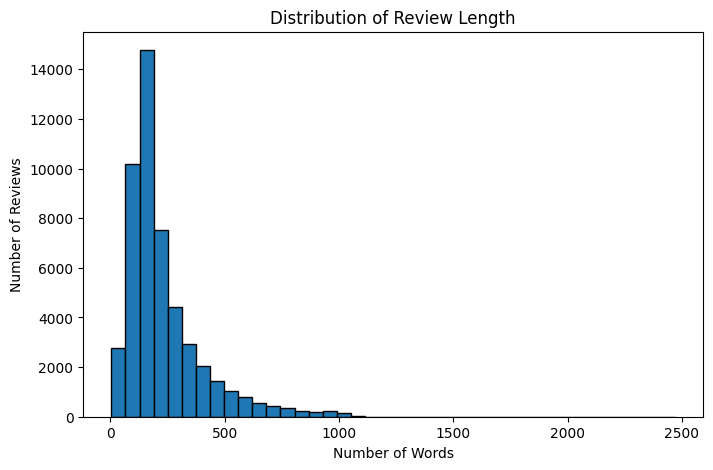


Total number of words: 11709196
Vocabulary size: 99420



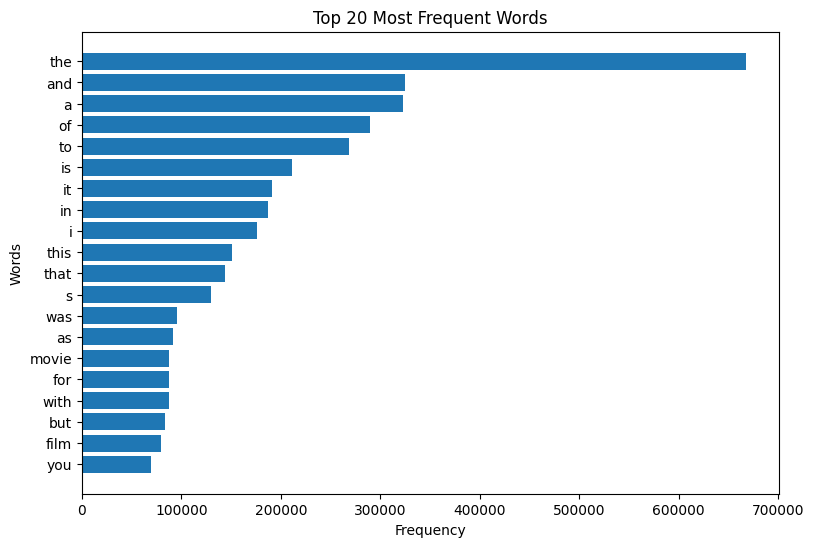

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

plt.hist(df['word_count'], bins = 40, edgecolor = 'black')
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")
plt.show()

all_words = " ".join(df['clean_text']).split()
print(f"\nTotal number of words: {len(all_words)}")
print(f"Vocabulary size: {len(set(all_words))}\n")

word_freq = Counter(all_words)
most_common_words = word_freq.most_common(20)
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

plt.figure(figsize = (9, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")
plt.show()

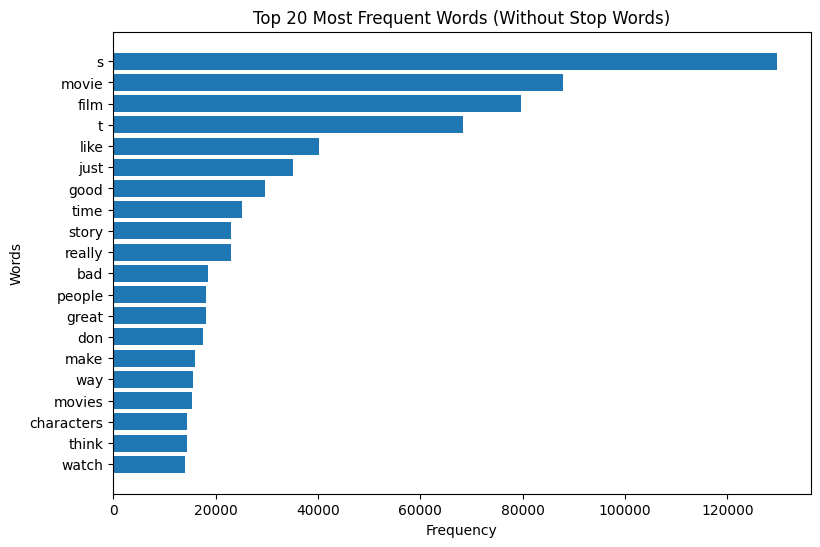

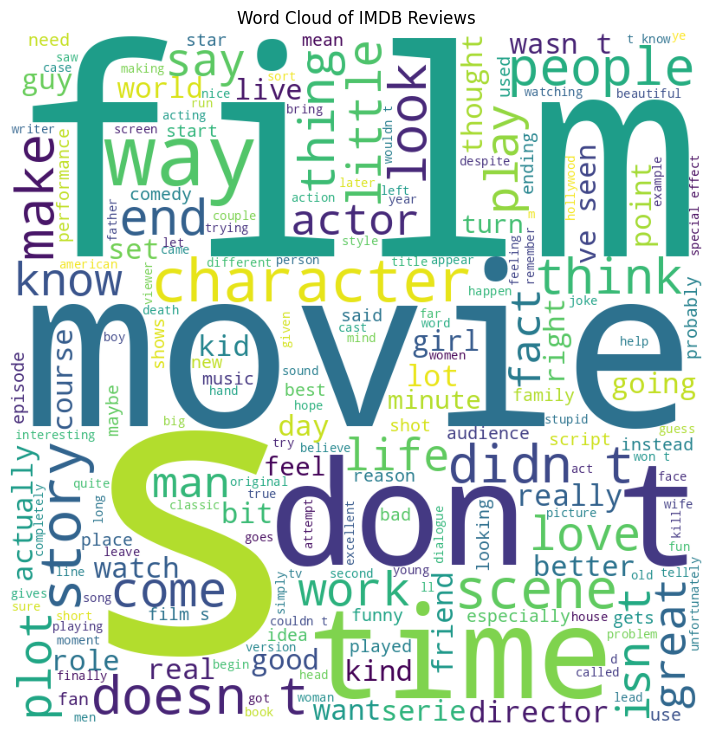


Top Bigrams:
             Bigram  Count
15          ve seen   4168
14  special effects   2250
0          don know   2202
6        low budget   1824
5        looks like   1679
18         year old   1601
8        movie just   1543
16       waste time   1526
2        good movie   1520
13           sci fi   1393
17      watch movie   1379
10         new york   1317
4         look like   1313
1         don think   1305
19        years ago   1256
12        real life   1240
3       high school   1164
7    main character   1140
11      pretty good   1120
9        movie like   1095


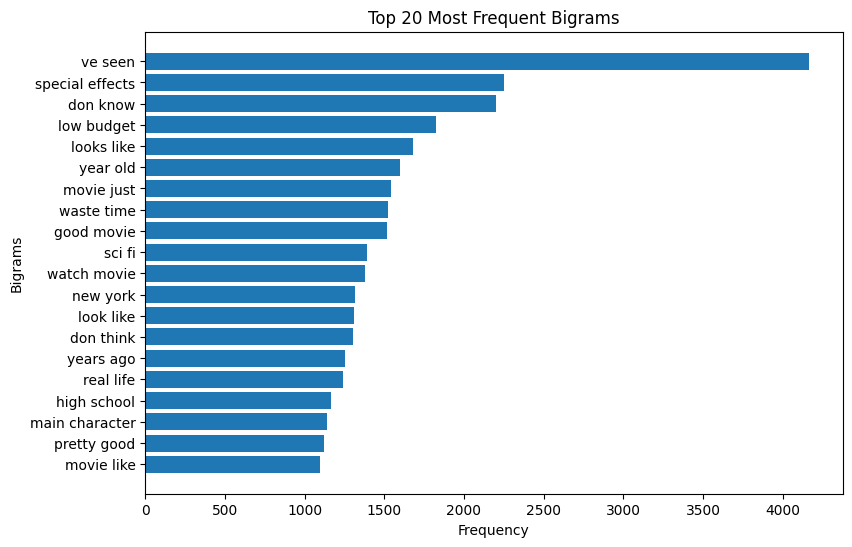

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

vectorizer = CountVectorizer(stop_words = "english")

vectorizer.fit(df['clean_text'])
stop_words = vectorizer.get_stop_words()

filtered_words = [word for word in all_words if word not in stop_words]
word_freq = Counter(filtered_words)
most_common_words = word_freq.most_common(20)
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

plt.figure(figsize = (9, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Without Stop Words)")
plt.show()

clean_text_combined = " ".join(filtered_words)

wordcloud = WordCloud(width = 800, height = 800, background_color = "white").generate(clean_text_combined)
plt.figure(figsize = (9, 9))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of IMDB Reviews")
plt.show()

bigram_vectorizer = CountVectorizer(ngram_range = (2, 2), stop_words = "english", max_features = 20)
bigram_matrix = bigram_vectorizer.fit_transform(df['clean_text'])
bigram_counts = bigram_matrix.sum(axis = 0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_df = pd.DataFrame({"Bigram": bigram_names, "Count": bigram_counts})
bigram_df = bigram_df.sort_values(by = "Count", ascending = False)
print("\nTop Bigrams:")
print(bigram_df)

plt.figure(figsize = (9, 6))
plt.barh(bigram_df["Bigram"][::-1], bigram_df["Count"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.title("Top 20 Most Frequent Bigrams")
plt.show()